### Setup

In [1]:
!./venv/bin/pip install kaggle scikit-learn numpy matplotlib seaborn kydavra


[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
!kaggle datasets download -d blastchar/telco-customer-churn --unzip

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
100%|█████████████████████████████████████████| 172k/172k [00:00<00:00, 541kB/s]



### Imports

In [106]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from kydavra import PointBiserialCorrSelector, ChiSquaredSelector, FisherSelector, LassoSelector, ReliefFSelector
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

Options

In [4]:
pd.set_option('display.expand_frame_repr', False)

### Data Collection

In [5]:
telco_df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(telco_df.describe())
telco_df.sample(5)

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
510,4332-MUOEZ,Male,1,Yes,Yes,20,Yes,No,Fiber optic,Yes,...,Yes,Yes,No,Yes,One year,No,Credit card (automatic),94.30,1818.3,No
6036,8008-ESFLK,Female,0,Yes,No,53,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,110.50,5835.5,No
2924,1428-GTBJJ,Male,0,No,No,11,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,74.55,824.75,Yes
5155,8294-UIMBA,Female,0,No,No,30,Yes,No,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Bank transfer (automatic),94.40,2638.1,No
4280,9135-HSWOC,Male,0,Yes,Yes,64,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),19.70,1274.05,No


#### Cleaning the Data

Checking for null values

In [6]:
telco_df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Checking for duplicates

In [7]:
telco_df.duplicated().sum()

np.int64(0)

Checking for empty values

In [8]:
(telco_df == " ").sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

We can see that customers with missing `TotalCharges` are those who have not stayed with the company for long enough (`telco` = 0 means it is their first month). In this case, `TotalCharges` should amount to zero, since these money have not reached the company account yet. Also, since it is their first month, they have not yet (had time to) leave the company, so the target column `Churn` is No.

In [9]:
telco_df[telco_df["TotalCharges"] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


Here it is confirmed that people with `tenure` equaling to 0 have no `TotalCharges`

In [10]:
telco_df[telco_df["tenure"] == 0].equals(telco_df[telco_df["TotalCharges"] == " "])

True

Drop ID columns

In [11]:
telco_df = telco_df.drop(columns=["customerID"])

Replace empty `TotalCharges` with zero

In [12]:
telco_df["TotalCharges"] = pd.to_numeric(telco_df["TotalCharges"].replace(" ", 0))

### EDA

In [13]:
x = telco_df.drop(columns='Churn').copy()
y = telco_df['Churn']

original_types = telco_df.dtypes.to_dict()

train_df, test_df = train_test_split(telco_df, test_size=0.3, stratify=telco_df['Churn'], random_state=42)

# Re-apply dtypes
train_df = train_df.astype(original_types)
test_df = test_df.astype(original_types)

train_df.info()

<class 'pandas.DataFrame'>
Index: 4930 entries, 5557 to 5639
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            4930 non-null   str    
 1   SeniorCitizen     4930 non-null   int64  
 2   Partner           4930 non-null   str    
 3   Dependents        4930 non-null   str    
 4   tenure            4930 non-null   int64  
 5   PhoneService      4930 non-null   str    
 6   MultipleLines     4930 non-null   str    
 7   InternetService   4930 non-null   str    
 8   OnlineSecurity    4930 non-null   str    
 9   OnlineBackup      4930 non-null   str    
 10  DeviceProtection  4930 non-null   str    
 11  TechSupport       4930 non-null   str    
 12  StreamingTV       4930 non-null   str    
 13  StreamingMovies   4930 non-null   str    
 14  Contract          4930 non-null   str    
 15  PaperlessBilling  4930 non-null   str    
 16  PaymentMethod     4930 non-null   str    
 17  MonthlyC

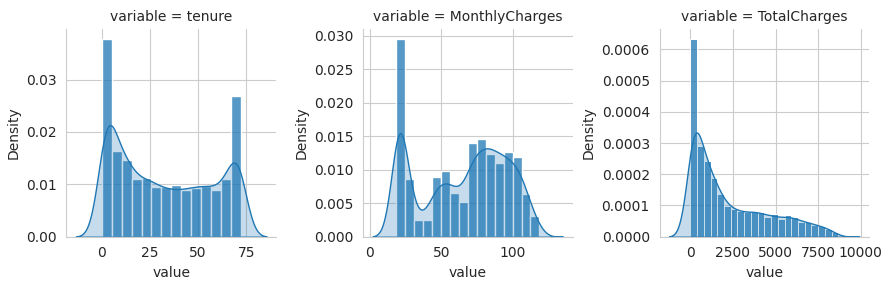

In [14]:
kde_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

with sns.axes_style('whitegrid'):
  nd = pd.melt(train_df, value_vars=kde_cols)
  n1 = sns.FacetGrid(nd, col='variable', col_wrap=3, sharex=False, sharey=False)

  n1.map(
      sns.histplot,
      'value',
      stat='density',
  )

  n1.map(
      sns.kdeplot,
      'value',
      fill=True
  )

/Users/maxim/Documents/work/sigmoid_hw/16_Feature_Selection/venv/lib/python3.13/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the countplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


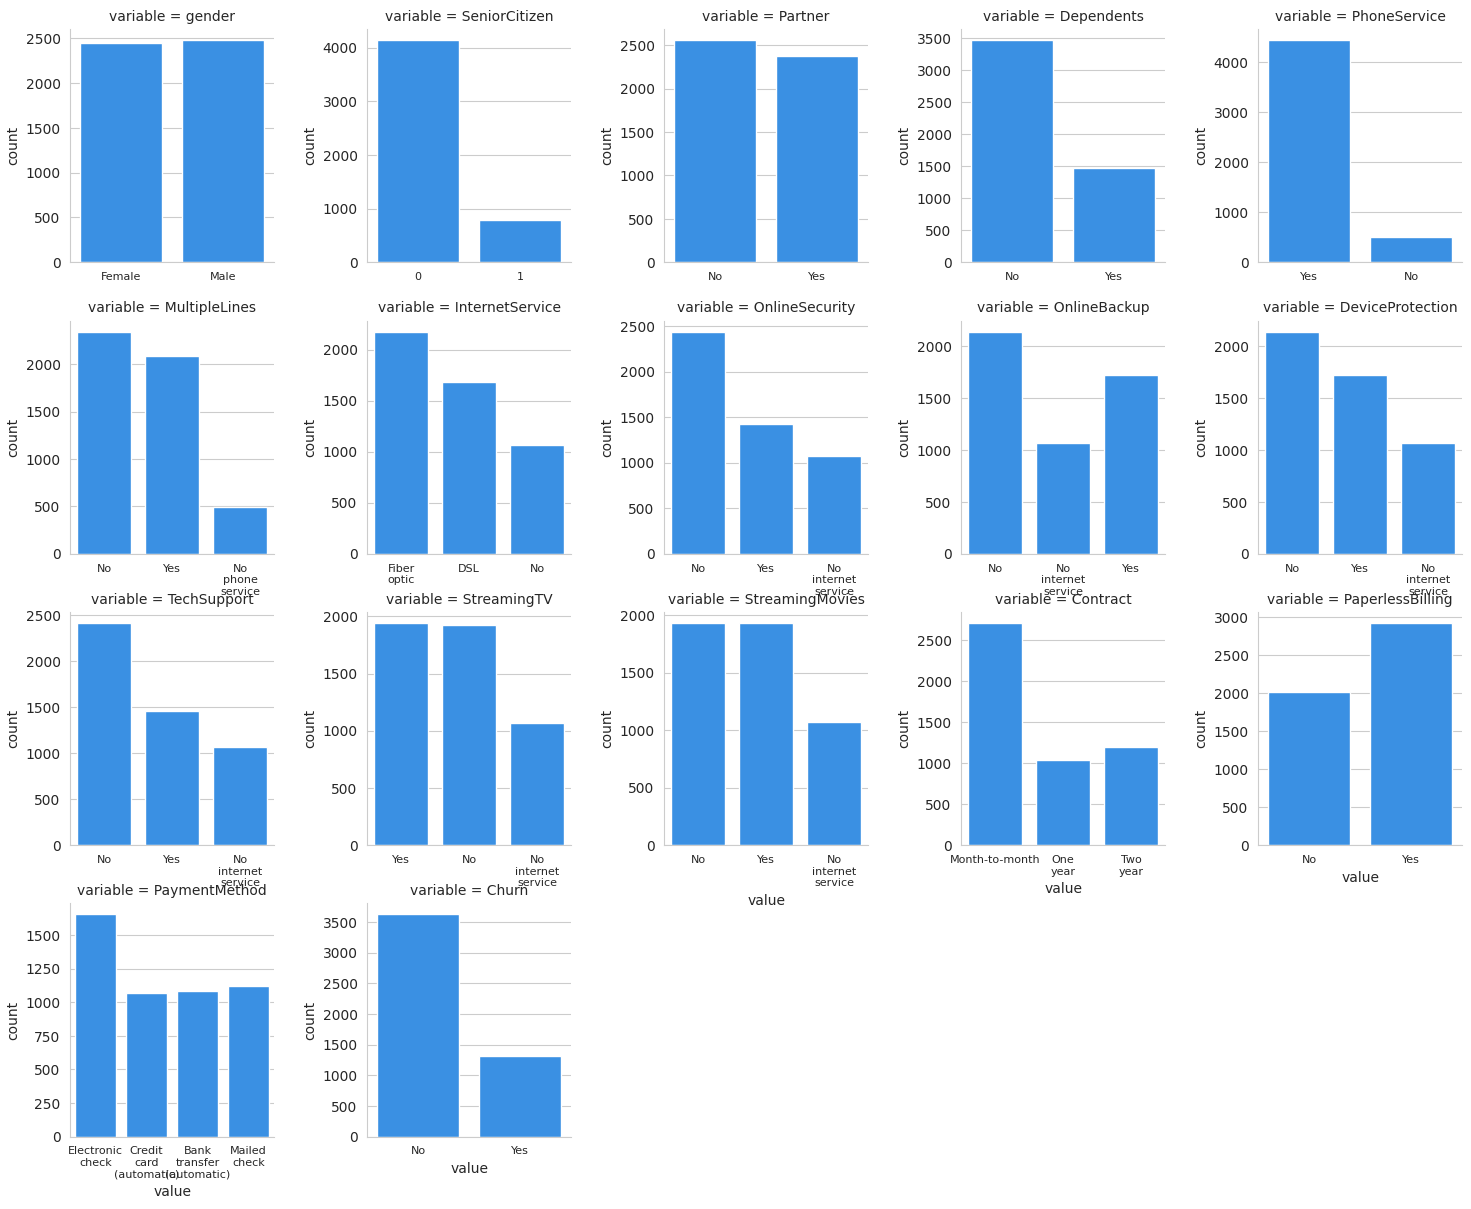

In [15]:
count_cols = train_df.drop(columns=kde_cols)
with sns.axes_style('whitegrid'):
  nd = pd.melt(train_df, value_vars=count_cols)
  n1 = sns.FacetGrid(nd, col='variable', col_wrap=5, sharex=False, sharey=False)
  n1 = n1.map(sns.countplot, 'value', color='#1e90ff', orient="h")

  for ax in n1.axes.flat:
      labels = [label.get_text().replace(" ", "\n") for label in ax.get_xticklabels()]
      ax.set_xticks(ax.get_xticks())
      ax.set_xticklabels(labels, fontsize=8)

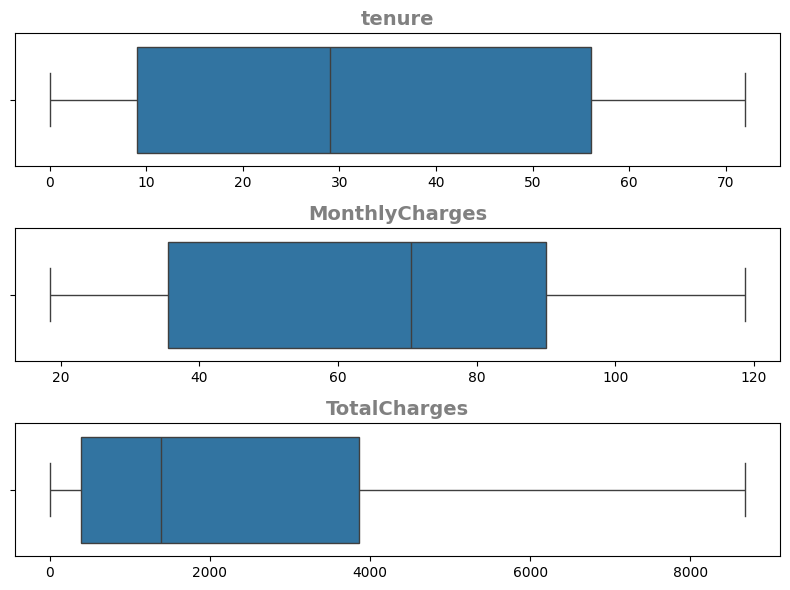

In [16]:
num_df = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(3,1,figsize=(8, 6))

counter = 0


for i in num_df:
    sns.boxplot(data=train_df,x=i,ax=axes[counter])

    axes[counter].set_title(
        f"{i}",
        fontsize=14,
        fontweight='bold',
        color='grey')
    axes[counter].set_xlabel("")

    counter+=1

plt.tight_layout()

  Churn   count         mean          std    min    25%       50%      75%      max
0    No  5174.0  2549.911442  2329.954215   0.00  572.9  1679.525  4262.85  8672.45
1   Yes  1869.0  1531.796094  1890.822994  18.85  134.5   703.550  2331.30  8684.80


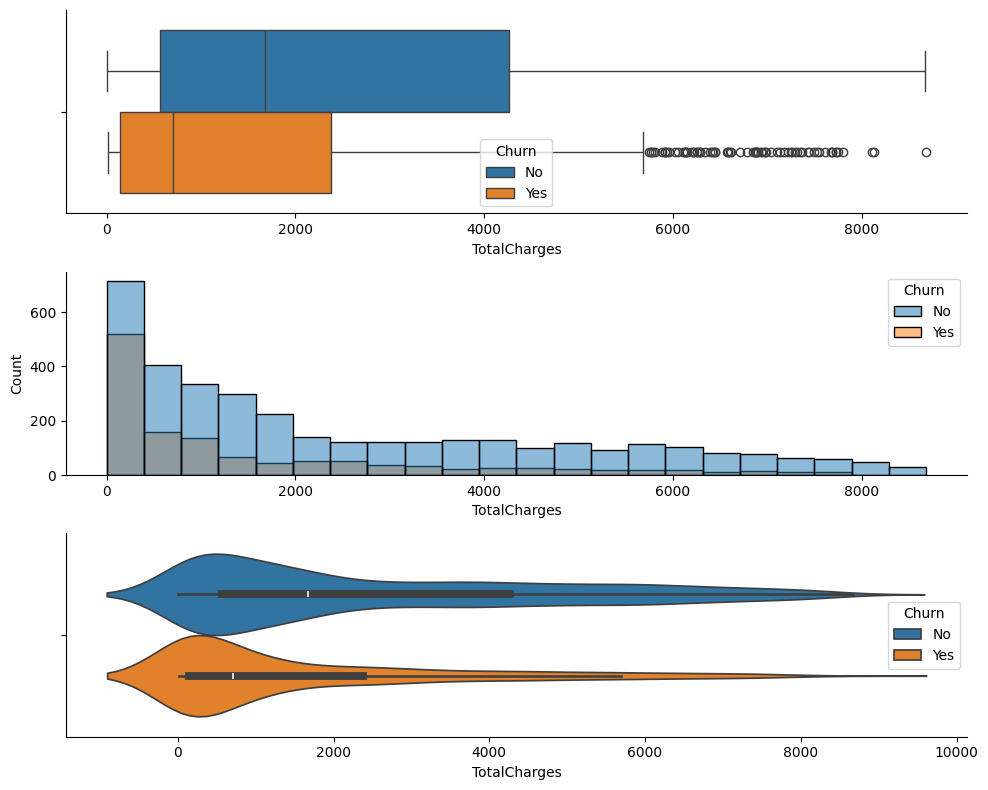

In [17]:
churn_rev = (
    telco_df.groupby('Churn')['TotalCharges']
    .describe()
    .reset_index()
)


print(churn_rev)

# show distributions
fig, axes = plt.subplots(3,1,figsize=(10,8))

sns.boxplot(
    data=train_df,
    x='TotalCharges',
    hue='Churn',
    ax=axes[0]
)

sns.histplot(
    data=train_df,
    x='TotalCharges',
    hue='Churn',
    ax=axes[1]
)

sns.violinplot(
    data=train_df,
    x='TotalCharges',
    hue='Churn',
    ax=axes[2]
)


# adjust visuals
plt.tight_layout()
sns.despine()

for i in range(3):
    axes[i].grid(False)

Those who churn are usually spending less than those who stay, which means that high prices are not driving them to leave the company. It might be a specific product, a combination product or not having a specific combo of services that drives them to choose another service provider. Let's check the relation between `tenure` and `TotalCharges`.

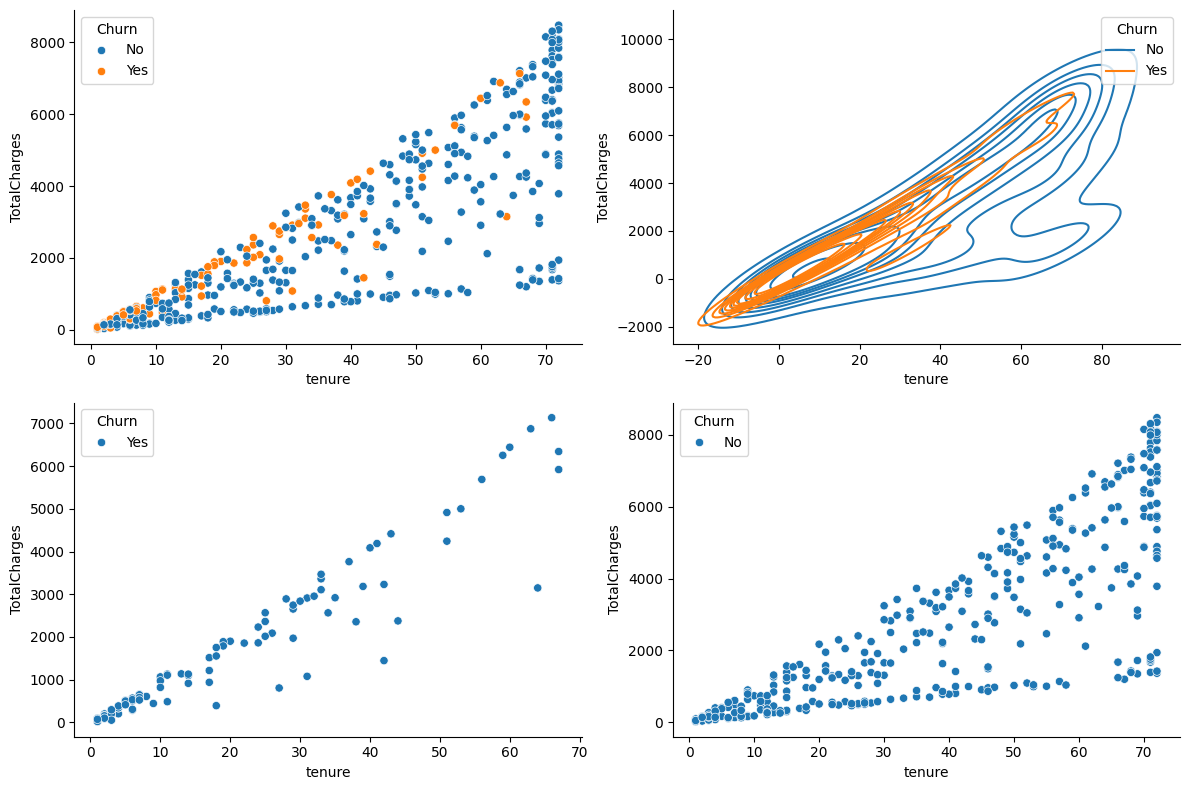

In [18]:
random_sample = train_df.sample(500,random_state=42).copy()

fig, axes = plt.subplots(2,2,figsize=(12,8))

sns.scatterplot(
    data=random_sample,
    x='tenure',#independent variable
    y='TotalCharges', # dependent variable
    hue='Churn',
    ax=axes[0,0]
)

sns.kdeplot(
    data=random_sample,
    x='tenure',#independent variable
    y='TotalCharges', # dependent variable
    hue='Churn',
    ax=axes[0,1]
)

# isolate the groups
sns.scatterplot(
    data=random_sample.loc[random_sample['Churn']=='Yes'],
    x='tenure',#independent variable
    y='TotalCharges', # dependent variable
    hue='Churn',
    ax=axes[1,0]
)

sns.scatterplot(
    data=random_sample.loc[random_sample['Churn']=='No'],
    x='tenure',#independent variable
    y='TotalCharges', # dependent variable
    hue='Churn',
    ax=axes[1,1]
)

# adjust the plots
for i in range(2):
    for j in range(2):
        axes[i,j].grid(False)


plt.tight_layout()
sns.despine()

There is an evident linear dependence between `tenure` and `TotalCharges` for Churn = Yes. From the KDE plot we can identify that churn most often happens in the first ten months for charges under 1000$. This group also overlaps with those whose churn = No, which suggests similar packages or service spendings. This will require further analysis.

  Churn   count      mean        std    min    25%    50%      75%     max
0    No  3622.0  61.32032  31.265296  18.40  25.10  64.45  88.5375  118.75
1   Yes  1308.0  75.00130  24.569710  18.85  56.25  80.00  94.4625  118.35


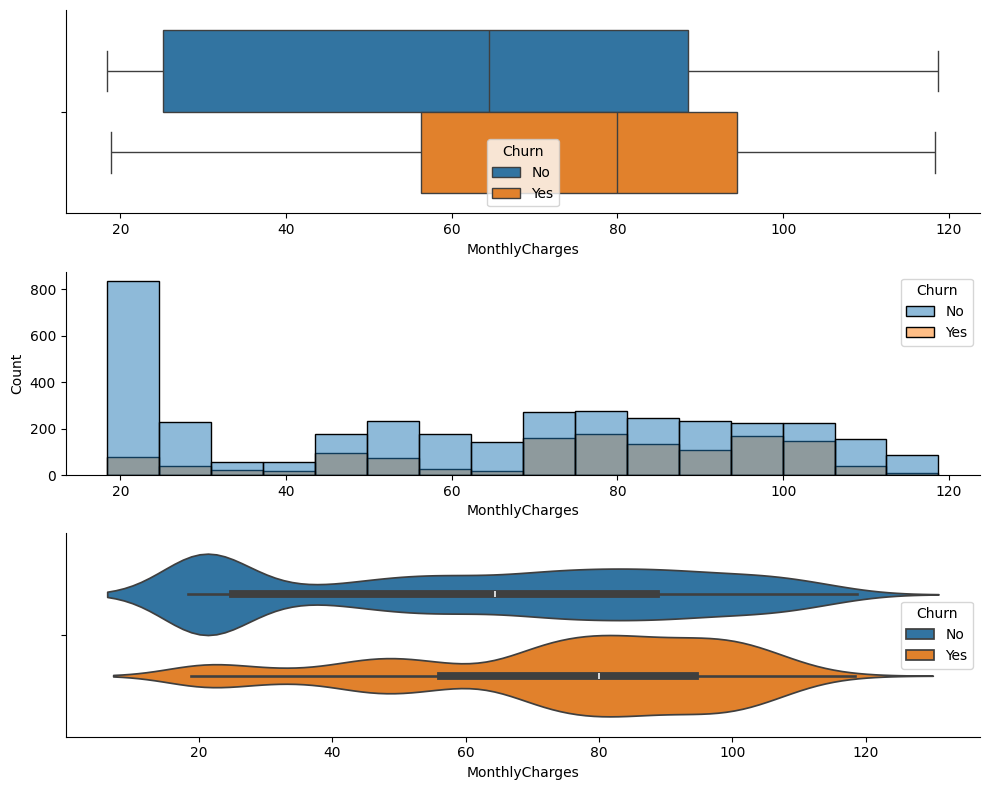

In [19]:
# review customer churn revenue
churn_rev = (
    train_df.groupby('Churn')['MonthlyCharges']
    .describe()
    .reset_index()
)


print(churn_rev)

# show distributions
fig, axes = plt.subplots(3,1,figsize=(10,8))

sns.boxplot(
    data=train_df,
    x='MonthlyCharges',
    hue='Churn',
    ax=axes[0]
);

sns.histplot(
    data=train_df,
    x='MonthlyCharges',
    hue='Churn',
    ax=axes[1]
);

sns.violinplot(
    data=train_df,
    x='MonthlyCharges',
    hue='Churn',
    ax=axes[2]
)


# adjust visuals
plt.tight_layout()
sns.despine()

for i in range(3):
    axes[i].grid(False)

Now we can see that those who churned were, on average, paying about 20$ more than those who have not. Those who havent churned are more concentrated in the lower values of MonthlyCharges, while those who have in the second half of the spectrum.

In [20]:
ob_df = telco_df.select_dtypes(include=["object", "string"]).copy()

n_unique = ob_df.nunique().sort_values()
unique_values = ob_df.apply(lambda x: x.unique())

pd.DataFrame(
    {
        "Unique Value Count":n_unique,
        "Unique Values":unique_values,
    }
)

,Unique Value Count,Unique Values
Churn,2,"[No, Yes]"
Contract,3,"[Month-to-month, One year, Two year]"
Dependents,2,"[No, Yes]"
DeviceProtection,3,"[No, Yes, No internet service]"
InternetService,3,"[DSL, Fiber optic, No]"
MultipleLines,3,"[No phone service, No, Yes]"
OnlineBackup,3,"[Yes, No, No internet service]"
OnlineSecurity,3,"[No, Yes, No internet service]"
PaperlessBilling,2,"[Yes, No]"
Partner,2,"[Yes, No]"


Most of the features have 2-4 unique values. `TotalCharges` column has float values, however some of them are repeating, indicating similar choices in selecting the services.

### Data Processing

Convert Categorical Columns

In [21]:
clean_df = telco_df.copy()

In [22]:
clean_df["gender"] = clean_df["gender"].map(lambda x: 1 if x == "Male" else 0)

In [23]:
yes_no_cols = ["PhoneService", "Partner", "Dependents", "PaperlessBilling", "Churn"]
clean_df[yes_no_cols] = clean_df[yes_no_cols].map(lambda x: 1 if x == "Yes" else 0)

I analyzed the correlation rate between columns with values "yes", "no" and "no internet service", and it showed that "no internet service" can appear in all appropriate columns, if the given customer does not have internet service. That means that for those columns, we can perform binary yes/no encoding and column "InternetService" will show internet availability.

I wanted to combine "no internet service" and "no phone service" in one column, but they had quite low correlation rate, so it is better keeping them apart.

In [24]:
yes_no_other = ["MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
clean_df[yes_no_other] = clean_df[yes_no_other].map(lambda x: 1 if x == "Yes" else 0)

For "Contract" columns, one and two year values have quite a high correlation rate to month-to-month. I decided to leave only one and two year columns, so that when both values are zero, it implies the contract is month-to-month

"PaymentMethod" column does not have such a high correlation rate between columns, but I thought it is also fine dropping the first categorical column.

In [25]:
drop_first_cols = ["Contract", "PaymentMethod"]

clean_df = pd.get_dummies(clean_df, columns=drop_first_cols, drop_first=True, dtype=int)

In [26]:
clean_df = pd.get_dummies(clean_df, columns=["InternetService"], drop_first=False, dtype=int)
# Dropping the "no" column, because if both columns are zero, that means the customer has no internet access
clean_df = clean_df.drop(columns=["InternetService_No"])

In [27]:
clean_df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_DSL,InternetService_Fiber optic
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,0,0,0,1,0,1,0
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,1,0,0,0,1,1,0
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,0,0,0,0,1,1,0
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,1,0,0,0,0,1,0
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,1,0,1,...,84.80,1990.50,0,1,0,0,0,1,1,0
7039,0,0,1,1,72,1,1,0,1,1,...,103.20,7362.90,0,1,0,1,0,0,0,1
7040,0,0,1,1,11,0,0,1,0,0,...,29.60,346.45,0,0,0,0,1,0,1,0
7041,1,1,1,0,4,1,1,0,0,0,...,74.40,306.60,1,0,0,0,0,1,0,1


### Feature Engineering

#### Correlation 

Since correlation selectors from kydavra have some bugs at the moment, I decided to do the correlation analysis myself using the `df.corr()` function

##### Find pairs of features whose absolute correlation is greater than threshold

In [28]:
threshold = 0.5

corr_matrix = clean_df.corr()

upper_mask = np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1)

corr_pairs_df = (
    corr_matrix.where(upper_mask)
    .stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "correlation"})
)

corr_pairs_df = corr_pairs_df[corr_pairs_df["correlation"].abs() > threshold] \
    .reset_index(drop=True) \
    .sort_values(by='correlation', ascending=False)

corr_pairs_df

,feature_1,feature_2,correlation
0,tenure,TotalCharges,0.826178
10,MonthlyCharges,InternetService_Fiber optic,0.787066
9,MonthlyCharges,TotalCharges,0.651174
5,StreamingTV,MonthlyCharges,0.629603
7,StreamingMovies,MonthlyCharges,0.627429
1,tenure,Contract_Two year,0.558533
4,StreamingTV,StreamingMovies,0.533094
3,DeviceProtection,TotalCharges,0.521983
8,StreamingMovies,TotalCharges,0.520122
6,StreamingTV,TotalCharges,0.514973


We can see that `TotalCharges` and `MonthlyCharges` are correlated to many other features in the dataset. This means that their distributions are quite similar, and hence carry the same information. These columns are candidates for deletion

##### Correlation to Target Column

In [29]:
clean_df.corr()["Churn"].sort_values(ascending=False)

Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling                         0.191825
SeniorCitizen                            0.150889
StreamingTV                              0.063228
StreamingMovies                          0.061382
MultipleLines                            0.040102
PhoneService                             0.011942
gender                                  -0.008612
DeviceProtection                        -0.066160
OnlineBackup                            -0.082255
PaymentMethod_Mailed check              -0.091683
InternetService_DSL                     -0.124214
PaymentMethod_Credit card (automatic)   -0.134302
Partner                                 -0.150448
Dependents                              -0.164221
TechSupport                             -0.164674
OnlineSecurity                          -0.171226


Columns like `gender` have almost zero correlation to the target column, and likely have no meaningful direct dependence. 

Positive correlation means that those features indicate that the customer is more likely to churn. Those attributes being the usage of fiber optic internet and electronic checks for payment.

Negative correlation means that those columns are more likely to preserve the customer. Longer tenure, long term contracts and higher spending amount indicate customer loyalty.

##### PointBiserialCorrSelector

In [50]:
point_biserial = PointBiserialCorrSelector(last_level=1)
point_biserial.select(clean_df, "Churn")

['tenure',
 'Contract_Two year',
 'PaymentMethod_Electronic check',
 'InternetService_Fiber optic']

##### ChiSquaredSelector

In [52]:
chi_squared = ChiSquaredSelector(significance_level=0.01)
chi_squared.select(clean_df, "Churn")

['SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'PaperlessBilling',
 'MonthlyCharges',
 'TotalCharges',
 'Contract_One year',
 'Contract_Two year',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check',
 'InternetService_DSL',
 'InternetService_Fiber optic']

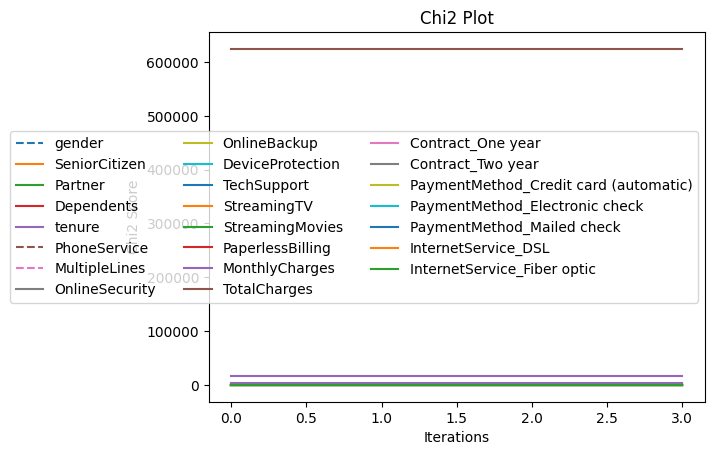

In [32]:
chi_squared.plot_chi2()

##### FisherSelector

Fisher score for feature selection is based on the variability of the feature between classes. If a feature values vary a lot for different classes, that means a higher Fisher score and the feature is deemed more useful for classification. Unfortunately, the library does not offer us the Fisher scores, so I copied the source code to print the fisher scores

In [33]:
fisher_df = clean_df[[col for col in clean_df.columns if col != "Churn"] + ["Churn"]]

fisher_selector = FisherSelector(n_features=6)
fisher_selector.select(fisher_df, "Churn")

['SeniorCitizen',
 'Contract_One year',
 'Contract_Two year',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Mailed check',
 'PhoneService']

In [34]:
target = 'Churn'
X = fisher_df.drop([target], axis=1).values
y = fisher_df[target].values

# Get the dimensionality of the fisher_df.
n_samples, n_features = X.shape

# Initialize the scores to 0.
score = np.zeros(n_features)

# Get the number of classes.
classes = np.unique(y).tolist()

# Initialize all the variables to 0.
n_k, mean_k, mean_fisher_df, std_fisher_df = 0, 0, 0, 0

# Iterating through every feature in the dataset.
for i in range(n_features):

    # Iterating through every class in the dataset.
    for c in classes:
        # Compute the size of the k-th class.
        n_k = fisher_df[target].value_counts().get(c)

        # Compute the mean of the k-th class.
        mean_k = fisher_df.groupby(target).mean()[
            fisher_df.columns[i]].get(c)

        # Compute the mean of the whole dataset.
        mean_fisher_df = fisher_df[fisher_df.columns[i]].mean()

        # Compute the standard deviation of the whole dataset.
        std_fisher_df = fisher_df[fisher_df.columns[i]].std()

        # Update the score.
        score[i] += (n_k * (mean_k - std_fisher_df)**2)

    # Update the score
    score[i] /= mean_fisher_df**2

pd.DataFrame(data={"column": fisher_df.drop([target], axis=1).columns, "fisher_score": score}).sort_values(by="fisher_score")

,column,fisher_score
0,gender,1.134555
2,Partner,179.047236
6,MultipleLines,220.991092
15,TotalCharges,274.071100
13,PaperlessBilling,382.335561
12,StreamingMovies,504.380406
11,StreamingTV,542.316963
4,tenure,913.020751
22,InternetService_Fiber optic,969.418397
9,DeviceProtection,1083.202793


`SeniorCitizen` has made its first appearance with the highest Fisher score, which means that it might be useful for training a classification model, though its correlation rate is not the best. Other features, like `Contract` and `PaymentMethod` have been seen before. `gender` is once again shown as a sub-par feature.

##### ReliefFSelector

Relief F selector ranks how similar a feature is to neighbors from the same class and how different for neighbors from other classes. Since it is a distance-based selector, it is sensitive to scale, which is why it needs to be scaled first.

In [46]:
target = "Churn"
relief_X = clean_df.drop(columns=[target]).copy()
relief_X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(relief_X),
    columns=relief_X.columns,
    index=relief_X.index,
 )

relief_df = pd.concat([relief_X_scaled, clean_df[[target]]], axis=1)

relief_selector = ReliefFSelector(n_neighbors=5)
relief_selector.select(relief_df, target)

['PhoneService',
 'InternetService_Fiber optic',
 'InternetService_DSL',
 'Contract_Two year',
 'PaymentMethod_Mailed check',
 'Contract_One year',
 'SeniorCitizen',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'Dependents']

In [49]:
X = relief_df.drop(columns=[target]).values
y = relief_df[target].values

n_neighbors = 5

# Get the dimensionality of the DataFrame.
n_samples, n_features = X.shape

# Initialize the scores to 0.
score = np.zeros(n_features)

# Identify neighbors for each sample (including all other rows).
nbrs = NearestNeighbors(n_neighbors=n_samples, algorithm="kd_tree").fit(X)
distances, indices = nbrs.kneighbors(X)

# Get the classes and their prior probabilities.
classes, class_counts = np.unique(y, return_counts=True)
class_priors = {label: count / n_samples for label, count in zip(classes, class_counts)}

# Iterating through every sample in the dataset.
for i in range(n_samples):
    row_class = y[i]
    neighbor_indices = indices[i, 1:]

    hit_indices = neighbor_indices[y[neighbor_indices] == row_class][:n_neighbors]

    if len(hit_indices) > 0:
        score -= np.sum(np.abs(X[i] - X[hit_indices]), axis=0) / len(hit_indices)

    for label in classes:
        if label == row_class:
            continue

        miss_indices = neighbor_indices[y[neighbor_indices] == label][:n_neighbors]

        if len(miss_indices) == 0:
            continue

        class_weight = class_priors[label] / (1 - class_priors[row_class])
        score += class_weight * np.sum(np.abs(X[i] - X[miss_indices]), axis=0) / len(miss_indices)

score /= n_samples

pd.DataFrame(
    {
        "column": relief_df.drop(columns=[target]).columns,
        "relief_f_score": score,
    }
).sort_values(by="relief_f_score", ascending=False)

,column,relief_f_score
17,Contract_Two year,0.228113
4,tenure,0.150631
16,Contract_One year,0.147118
3,Dependents,0.104146
18,PaymentMethod_Credit card (automatic),0.095557
0,gender,0.092238
13,PaperlessBilling,0.091879
6,MultipleLines,0.084814
15,TotalCharges,0.074226
2,Partner,0.070295


##### LassoSelector

Uses L1 regularization to choose the features that do not shrink zero. After playing with different parameters, it seems like all features tend to zero.

In [63]:
lasso_selector = LassoSelector(alpha_start=0.0001, alpha_finish=0.001, n_alphas=500, extend_step=10)
lasso_selector.select(clean_df, "Churn")

[]

I selected features that appear at least twice across all selectors

In [69]:
selected_features = ['Contract_Two year', 'tenure', 'PaymentMethod_Credit card (automatic)', 'Contract_One year', 'TotalCharges', 'PaymentMethod_Electronic check', 'InternetService_Fiber optic', 'SeniorCitizen', 'Partner', 'Dependents', 'PaymentMethod_Mailed check', 'PaperlessBilling']

### Data Splitting

In [ ]:
X = clean_df[selected_features]
y = clean_df["Churn"]

### Model Training & Evaluation

#### Training on Entire Dataset

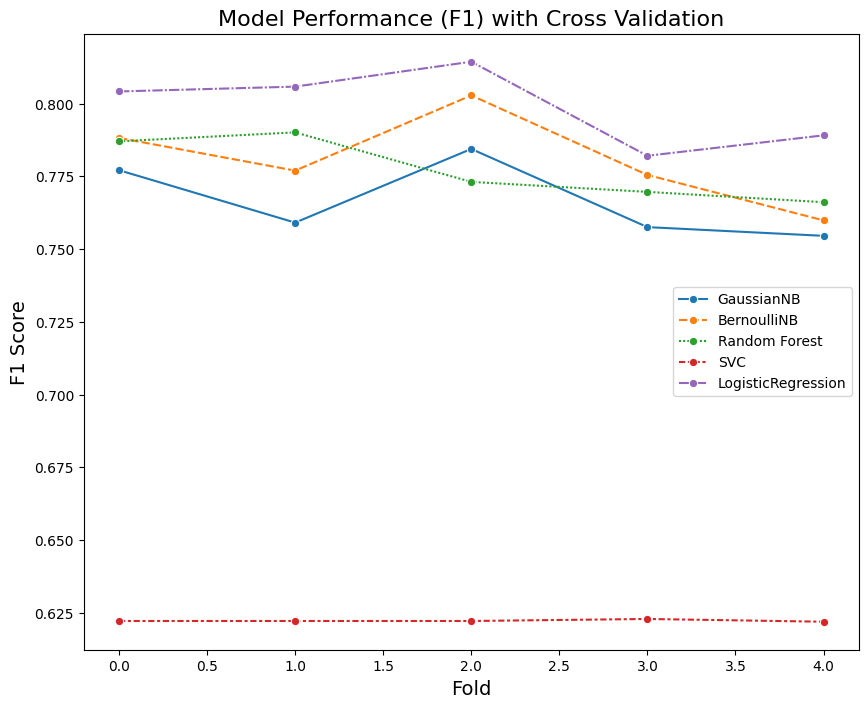

In [116]:
scaled_cols = ["tenure", "TotalCharges"]
preprocessor = ColumnTransformer(
    transformers=[("scaler", StandardScaler(), scaled_cols)],
    remainder="passthrough"
)

classifiers = {
    # "MultinomialNB": MultinomialNB(),
    "GaussianNB": GaussianNB(),
    "BernoulliNB": BernoulliNB(),
    "Random Forest": RandomForestClassifier(),
    "SVC": SVC(),
    "LogisticRegression": LogisticRegression(max_iter=500)
}

# set up kfold - maintain the stratified sampling
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# create empty dict for scores
model_score = {}

for model_name, clf in classifiers.items():
    pipeline = Pipeline([("preprocessor", preprocessor), ("classifier", clf)])
    scores = cross_val_score(pipeline, clean_df.drop("Churn", axis=1), clean_df["Churn"], cv=kf, scoring='f1_weighted')
    model_score[model_name] = scores



#Visualise the results
plt.figure(figsize=(10,8))

ax = sns.lineplot(
    pd.DataFrame(model_score),
    marker='o',
    linestyle="--"
)

plt.legend()

ax.set_title(
    'Model Performance (F1) with Cross Validation', 
    fontsize=16
)

ax.set_xlabel(
    'Fold', 
    fontsize=14
)


ax.set_ylabel(
    'F1 Score', 
    fontsize=14
)

ax.grid(False)

##### Average F1 score for each model

In [117]:
pd.DataFrame(model_score).aggregate("mean", axis=0).sort_values(ascending=False)

LogisticRegression    0.799124
BernoulliNB           0.780675
Random Forest         0.777210
GaussianNB            0.766550
SVC                   0.622244
dtype: float64

#### Training only on Selected Features

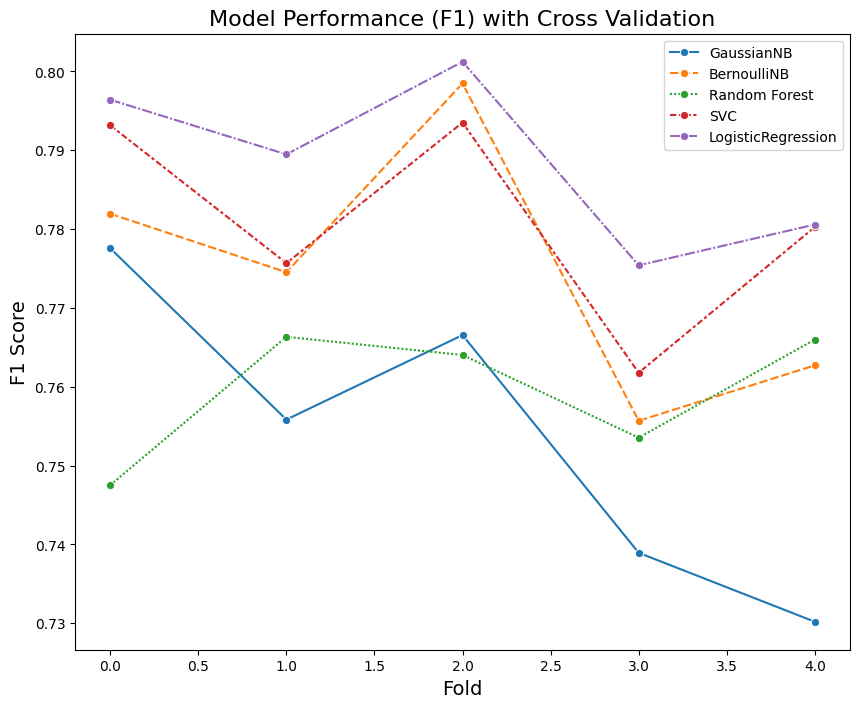

In [ ]:
scaled_cols = ["tenure", "TotalCharges"]
preprocessor = ColumnTransformer(
    transformers=[("scaler", StandardScaler(), scaled_cols)],
    remainder="passthrough"
)

classifiers = {
    # "MultinomialNB": MultinomialNB(),
    "GaussianNB": GaussianNB(),
    "BernoulliNB": BernoulliNB(),
    "Random Forest": RandomForestClassifier(),
    "SVC": SVC(),
    "LogisticRegression": LogisticRegression(max_iter=500)
}

# set up kfold - maintain the stratified sampling
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# create empty dict for scores
model_score = {}

for model_name, clf in classifiers.items():
    pipeline = Pipeline([("preprocessor", preprocessor), ("classifier", clf)])
    scores = cross_val_score(pipeline, X, y, cv=kf, scoring='f1_weighted')
    model_score[model_name] = scores



#Visualise the results
plt.figure(figsize=(10,8))

ax = sns.lineplot(
    pd.DataFrame(model_score),
    marker='o',
    linestyle="--"
)

plt.legend()

ax.set_title(
    'Model Performance (F1) with Cross Validation', 
    fontsize=16
)

ax.set_xlabel(
    'Fold', 
    fontsize=14
)


ax.set_ylabel(
    'F1 Score', 
    fontsize=14
)

ax.grid(False)

##### Average F1 score for each model

In [112]:
pd.DataFrame(model_score).aggregate("mean", axis=0).sort_values(ascending=False)

LogisticRegression    0.788621
SVC                   0.780879
BernoulliNB           0.774672
Random Forest         0.759484
GaussianNB            0.753819
dtype: float64

##### Confusion Matrices for each Model

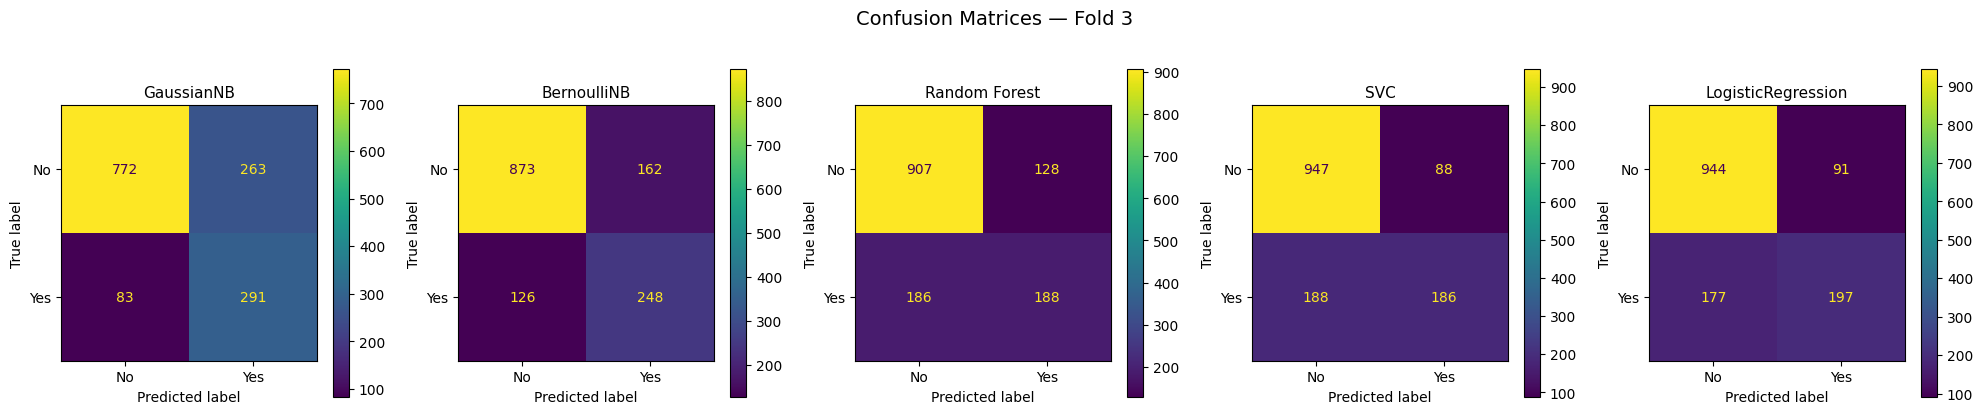

In [114]:
fold_3_train_idx, fold_3_test_idx = list(kf.split(X, y))[2]

X_fold_train, X_fold_test = X.iloc[fold_3_train_idx], X.iloc[fold_3_test_idx]
y_fold_train, y_fold_test = y.iloc[fold_3_train_idx], y.iloc[fold_3_test_idx]

n_models = len(classifiers)
fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))

for ax, (model_name, clf) in zip(axes, classifiers.items()):
    pipeline = Pipeline([("preprocessor", preprocessor), ("classifier", clf)])
    pipeline.fit(X_fold_train, y_fold_train)
    y_fold_pred = pipeline.predict(X_fold_test)

    ConfusionMatrixDisplay.from_predictions(y_fold_test, y_fold_pred, ax=ax)
    ax.set_title(model_name, fontsize=11)

fig.suptitle("Confusion Matrices — Fold 3", fontsize=14, y=1.02)
plt.tight_layout()
